# Adversarial Attacks using API

In [1]:
from advsecurenet.computer_vision.image_classification.attacks.gradient_based import FGSM, LOTS
from advsecurenet.shared.types.configs.attack_configs import (
    FgsmAttackConfig,
    LotsAttackConfig,
)
from advsecurenet.shared.types.configs.attack_configs.attacker_config import (
    AttackerConfig,
)
from advsecurenet.models.model_factory import ModelFactory
from advsecurenet.datasets.dataset_factory import DatasetFactory
from advsecurenet.computer_vision.image_classification.attacks.attacker import Attacker
from advsecurenet.dataloader.data_loader_factory import DataLoaderFactory
from advsecurenet.shared.types.configs.preprocess_config import (
    PreprocessConfig,
    PreprocessStep,
)
from advsecurenet.shared.types.configs.device_config import DeviceConfig
from advsecurenet.utils.adversarial_target_generator import AdversarialTargetGenerator
from advsecurenet.datasets.targeted_adv_dataset import AdversarialDataset

from tqdm.auto import tqdm

import numpy as np

from matplotlib import pyplot as plt

/home/user/arutkiewicz/advsecurenet/code/advsecurenet_mp/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Define the model
model = ModelFactory.create_model(
    model_name="resnet18", num_classes=10, pretrained=True
)

In [3]:
# Lets define the preprocessing configuration we want to use
preprocess_config = PreprocessConfig(
    steps=[
        PreprocessStep(name="Resize", params={"size": 32}),
        PreprocessStep(name="CenterCrop", params={"size": 32}),
        PreprocessStep(name="ToTensor"),
        PreprocessStep(
            name="ToDtype", params={"dtype": "torch.float32", "scale": True}
        ),
        PreprocessStep(
            name="Normalize",
            params={"mean": [0.485, 0.456, 0.406], "std": [0.229, 0.224, 0.225]},
        ),
    ]
)

# Define the dataset
dataset = DatasetFactory.create_dataset(
    dataset_type="cifar10", preprocess_config=preprocess_config, return_loaded=False
)
test_data = dataset.load_dataset(train=False)

/home/user/arutkiewicz/advsecurenet/code/advsecurenet_mp/.venv/lib/python3.11/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [4]:
# Define the dataloder
dataloader = DataLoaderFactory.create_dataloader(dataset=test_data, batch_size=32)

In [5]:
# define the device config
device = DeviceConfig(processor="cuda:6")

# Define the fgsm config
fgsm_config = FgsmAttackConfig(
    targeted=False,
    epsilon=0.1,
    device=device,
)

# Now we can define the attack
attack = FGSM(config=fgsm_config)

## Untargeted FGSM

### Option 1. Using the Attacker

You can use the `Attacker` to run the attack and return the adversarial images in the end. This helps you not to worry about the attack loop and focus on the attack parameters.

In [6]:
# define the attacker
attacker_config = AttackerConfig(
    model=model,
    attack=attack,
    dataloader=dataloader,
    device=device,
    return_adversarial_images=True,
)

attacker = Attacker(config=attacker_config)

In [7]:
adv_imgs = attacker.execute()

Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/lib/python3.11/multiprocessing/util.py", line 300, in _run_finalizers
    finalizer()
  File "/usr/lib/python3.11/multiprocessing/util.py", line 300, in _run_finalizers
    finalizer()
  File "/usr/lib/python3.11/multiprocessing/util.py", line 300, in _run_finalizers
    finalizer()
  File "/usr/lib/python3.11/multiprocessing/util.py", line 224, in __call__
    res = self._callback(*self._args, **self._kwargs)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/multiprocessing/util.py", line 224, in __call__
    res = self._callback(*self._args, **self._kwargs)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/multiprocessing/util.py", line 300, in _run_finalizers
    finalizer()
  File "/usr/lib/python3.11/multiprocessing/util.py", line 133, in _remove_temp_dir
    rmtree(t

Attack Success Rate: 0.8460


Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/lib/python3.11/multiprocessing/util.py", line 300, in _run_finalizers
    finalizer()
  File "/usr/lib/python3.11/multiprocessing/util.py", line 300, in _run_finalizers
    finalizer()
  File "/usr/lib/python3.11/multiprocessing/util.py", line 300, in _run_finalizers
    finalizer()
  File "/usr/lib/python3.11/multiprocessing/util.py", line 224, in __call__
    res = self._callback(*self._args, **self._kwargs)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/multiprocessing/util.py", line 224, in __call__
    res = self._callback(*self._args, **self._kwargs)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/multiprocessing/util.py", line 300, in _run_finalizers
    finalizer()
  File "/usr/lib/python3.11/multiprocessing/util.py", line 224, in __call__
    res = self._call

### Option 2. Manual Iteration
If you prefer to manually run the attack, you can loop through the dataloader to generate the adversarial samples.

In [8]:
for images, labels in tqdm(dataloader, desc="Attacking"):
    model = model.to(device.processor)
    images, labels = images.to(device.processor), labels.to(device.processor)
    adv_imgs = attack.attack(model, images, labels)
    break

Attacking:   0%|          | 0/313 [00:00<?, ?it/s]Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/lib/python3.11/multiprocessing/util.py", line 300, in _run_finalizers
    finalizer()
  File "/usr/lib/python3.11/multiprocessing/util.py", line 300, in _run_finalizers
    finalizer()
  File "/usr/lib/python3.11/multiprocessing/util.py", line 300, in _run_finalizers
    finalizer()
  File "/usr/lib/python3.11/multiprocessing/util.py", line 300, in _run_finalizers
    finalizer()
  File "/usr/lib/python3.11/multiprocessing/util.py", line 224, in __call__
    res = self._callback(*self._args, **self._kwargs)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/multiprocessing/util.py", line 224, in __call__
    res = self._callback(*self._args, **self._kwargs)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/multiprocessing/ut

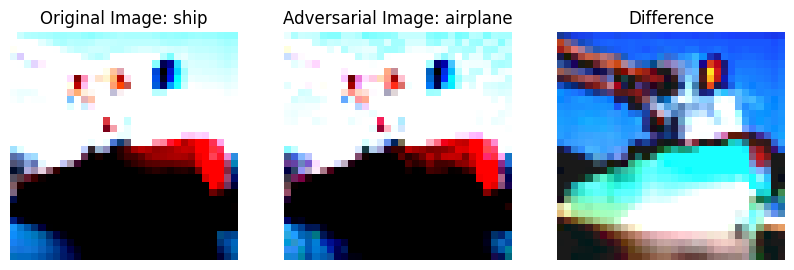

In [9]:
# Sampling results
bening_pred = model(images).argmax(dim=1)
adv_pred = model(adv_imgs).argmax(dim=1)

cifar10_classes = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
]

index = -1

# find a index that benign prediction is equal to the label but adversarial prediction is not equal to the label
for i in range(len(bening_pred)):
    index += 1
    if bening_pred[index] == labels[index] and adv_pred[index] != labels[index]:
        break

bening_image = images[index].cpu().numpy().transpose(1, 2, 0)
adv_image = adv_imgs[index].cpu().numpy().transpose(1, 2, 0)
diff = np.abs(bening_image - adv_image)

bening_prediction = cifar10_classes[bening_pred[index]]
adv_prediction = cifar10_classes[adv_pred[index]]

plt.figure(figsize=(10, 10))
plt.subplot(1, 3, 1)
plt.imshow(bening_image)
plt.title(f"Original Image: {bening_prediction}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(adv_image)
plt.title(f"Adversarial Image: {adv_prediction}")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(diff)
plt.title("Difference")
plt.axis("off")

plt.show()

## Targeted FGSM

We can also run the targeted FGSM Attack. We will utilize the `AdversarialTargetGenerator` to generate the target labels for the attack.

In [10]:
# create adversarial target generator
target_generator = AdversarialTargetGenerator()

# Adversarial Target Generator uses indices mapping to generate target labels. By setting overwrite=True, it will overwrite the existing target labels if they exist.
target_labels = target_generator.generate_target_labels(data=test_data, overwrite=True)

# We can create a new dataset with the adversarial target labels. This will be used during the attack.
adv_data = AdversarialDataset(
    base_dataset=test_data,
    target_labels=target_labels,
)

# Since we have a new dataset, we need to create a new dataloader
targeted_dataloader = DataLoaderFactory.create_dataloader(
    dataset=adv_data, batch_size=32
)

targeted_fgsm_config = FgsmAttackConfig(
    targeted=True,
    epsilon=0.1,
    device=device,
)

targeted_fgsm = FGSM(config=targeted_fgsm_config)

## Option 1. Using the Attacker
From this point everything is the same as the untargeted attack. We again have two options to run the attack. Either use the `Attacker` or manually iterate through the dataloader.

In [11]:
targeted_attacker_config = AttackerConfig(
    model=model,
    attack=targeted_fgsm,
    dataloader=targeted_dataloader,
    device=device,
    return_adversarial_images=True,
)

targeted_fgsm_attacker = Attacker(config=targeted_attacker_config)

# Now we can execute the attack
targeted_adv_imgs = targeted_fgsm_attacker.execute()

Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/lib/python3.11/multiprocessing/util.py", line 300, in _run_finalizers
    finalizer()
  File "/usr/lib/python3.11/multiprocessing/util.py", line 300, in _run_finalizers
    finalizer()
Traceback (most recent call last):
  File "/usr/lib/python3.11/multiprocessing/util.py", line 300, in _run_finalizers
    finalizer()
  File "/usr/lib/python3.11/multiprocessing/util.py", line 224, in __call__
    res = self._callback(*self._args, **self._kwargs)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/multiprocessing/util.py", line 224, in __call__
    res = self._callback(*self._args, **self._kwargs)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/multiprocessing/util.py", line 224, in __call__
    res = self._callback(*self._args, **self._kwargs)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/us

Attack Success Rate: 0.1532


Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/lib/python3.11/multiprocessing/util.py", line 300, in _run_finalizers
    finalizer()
  File "/usr/lib/python3.11/multiprocessing/util.py", line 224, in __call__
    res = self._callback(*self._args, **self._kwargs)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
Traceback (most recent call last):
  File "/usr/lib/python3.11/multiprocessing/util.py", line 133, in _remove_temp_dir
    rmtree(tempdir)
  File "/usr/lib/python3.11/multiprocessing/util.py", line 300, in _run_finalizers
    finalizer()
  File "/usr/lib/python3.11/multiprocessing/util.py", line 224, in __call__
    res = self._callback(*self._args, **self._kwargs)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/shutil.py", line 732, in rmtree
    _rmtree_safe_fd(fd, path, onerror)
  File "/usr/lib/python3.11/multiprocessing/util.py", line 300, in _run_finalizers
    fina

### Option 2. Manual Iteration

This step is almost identical to the untargeted attack. The only difference is here we need to loop through the new dataloader that contains the target labels.

In [12]:
for images, labels, target_labels, _ in tqdm(targeted_dataloader, desc="Attacking"):
    model = model.to(device.processor)
    images, labels, target_labels = (
        images.to(device.processor),
        labels.to(device.processor),
        target_labels.to(device.processor),
    )
    # Note that we are passing the target labels to the attack function
    adv_imgs = attack.attack(model, images, target_labels)

Attacking:   0%|          | 0/313 [00:00<?, ?it/s]Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/lib/python3.11/multiprocessing/util.py", line 300, in _run_finalizers
    finalizer()
  File "/usr/lib/python3.11/multiprocessing/util.py", line 224, in __call__
    res = self._callback(*self._args, **self._kwargs)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/multiprocessing/util.py", line 133, in _remove_temp_dir
    rmtree(tempdir)
  File "/usr/lib/python3.11/shutil.py", line 732, in rmtree
    _rmtree_safe_fd(fd, path, onerror)
  File "/usr/lib/python3.11/shutil.py", line 683, in _rmtree_safe_fd
    onerror(os.unlink, fullname, sys.exc_info())
Traceback (most recent call last):
  File "/usr/lib/python3.11/multiprocessing/util.py", line 300, in _run_finalizers
    finalizer()
  File "/usr/lib/python3.11/shutil.py", line 681, in _rmtree_safe_fd
    os.unlink(entry.name, dir_fd=topfd)
  File "/usr/lib/python3.11/multi

RuntimeError: 0D or 1D target tensor expected, multi-target not supported

## LOTS Attack

Targeted attacks need target labels to be specified, which is used by the attack to get closer to. `LOTS` attack is a targeted attack, in addition to the target labels it also expects the target images to be specified. With the huge dataset, it is not feasible to specify the target images manually. Therefore, `advsecurenet` provides a way to generate the target images automatically.

In [ ]:
# We need to generate target images and labels for the targeted attack
target_images, target_labels = target_generator.generate_target_images_and_labels(
    data=test_data, overwrite=True
)

# Again lets create a new dataset with the target images and labels
lots_dataset = AdversarialDataset(
    base_dataset=test_data,
    target_images=target_images,
    target_labels=target_labels,
)

# And a new dataloader
lots_dataloader = DataLoaderFactory.create_dataloader(
    dataset=lots_dataset, batch_size=32
)

### Option 1. Using the Attacker


In [ ]:
# LOTS attack expects a deep feature layer to be passed as an argument. We can get the deep feature layer from the model
model.get_layer_names()

['x',
 'conv1',
 'bn1',
 'relu',
 'maxpool',
 'layer1.0.conv1',
 'layer1.0.bn1',
 'layer1.0.relu',
 'layer1.0.conv2',
 'layer1.0.bn2',
 'layer1.0.add',
 'layer1.0.relu_1',
 'layer1.1.conv1',
 'layer1.1.bn1',
 'layer1.1.relu',
 'layer1.1.conv2',
 'layer1.1.bn2',
 'layer1.1.add',
 'layer1.1.relu_1',
 'layer2.0.conv1',
 'layer2.0.bn1',
 'layer2.0.relu',
 'layer2.0.conv2',
 'layer2.0.bn2',
 'layer2.0.downsample.0',
 'layer2.0.downsample.1',
 'layer2.0.add',
 'layer2.0.relu_1',
 'layer2.1.conv1',
 'layer2.1.bn1',
 'layer2.1.relu',
 'layer2.1.conv2',
 'layer2.1.bn2',
 'layer2.1.add',
 'layer2.1.relu_1',
 'layer3.0.conv1',
 'layer3.0.bn1',
 'layer3.0.relu',
 'layer3.0.conv2',
 'layer3.0.bn2',
 'layer3.0.downsample.0',
 'layer3.0.downsample.1',
 'layer3.0.add',
 'layer3.0.relu_1',
 'layer3.1.conv1',
 'layer3.1.bn1',
 'layer3.1.relu',
 'layer3.1.conv2',
 'layer3.1.bn2',
 'layer3.1.add',
 'layer3.1.relu_1',
 'layer4.0.conv1',
 'layer4.0.bn1',
 'layer4.0.relu',
 'layer4.0.conv2',
 'layer4.0.bn2',

In [ ]:
# Lets define the lots config. We pick fc as the deep feature layer
lots_config = LotsAttackConfig(
    device=device, epsilon=0.1, targeted=True, deep_feature_layer="fc"
)

# And create the attack
lots_attack = LOTS(config=lots_config)

In [ ]:
# Lets define the attacker config again
lots_attacker_config = AttackerConfig(
    model=model,
    attack=lots_attack,
    dataloader=lots_dataloader,
    device=device,
    return_adversarial_images=True,
)

lots_attacker = Attacker(config=lots_attacker_config)

# Now we can execute the attack
lots_adv_imgs = lots_attacker.execute()

Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/lib/python3.11/multiprocessing/util.py", line 300, in _run_finalizers
    finalizer()
  File "/usr/lib/python3.11/multiprocessing/util.py", line 300, in _run_finalizers
    finalizer()
  File "/usr/lib/python3.11/multiprocessing/util.py", line 300, in _run_finalizers
    finalizer()
  File "/usr/lib/python3.11/multiprocessing/util.py", line 300, in _run_finalizers
    finalizer()
  File "/usr/lib/python3.11/multiprocessing/util.py", line 224, in __call__
    res = self._callback(*self._args, **self._kwargs)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/multiprocessing/util.py", line 224, in __call__
    res = self._callback(*self._args, **self._kwargs)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/multiprocessing/util.py", line 224, in __call__
    res = self._call

Attack Success Rate: 0.1049


Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/lib/python3.11/multiprocessing/util.py", line 300, in _run_finalizers
    finalizer()
  File "/usr/lib/python3.11/multiprocessing/util.py", line 300, in _run_finalizers
    finalizer()
  File "/usr/lib/python3.11/multiprocessing/util.py", line 300, in _run_finalizers
    finalizer()
  File "/usr/lib/python3.11/multiprocessing/util.py", line 300, in _run_finalizers
    finalizer()
  File "/usr/lib/python3.11/multiprocessing/util.py", line 224, in __call__
    res = self._callback(*self._args, **self._kwargs)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/multiprocessing/util.py", line 224, in __call__
    res = self._callback(*self._args, **self._kwargs)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/multiprocessing/util.py", line 224, in __call__
    res = self._call

### Option 2. Manual Iteration

If you prefer to manually run the attack, you can loop through the dataloader to generate the adversarial samples. 


In [ ]:
for images, labels, target_labels, target_images in tqdm(
    lots_dataloader, desc="Attacking"
):
    model = model.to(device.processor)
    images, labels, target_labels, target_images = (
        images.to(device.processor),
        labels.to(device.processor),
        target_labels.to(device.processor),
        target_images.to(device.processor),
    )
    # Note that we are passing the target labels to the attack function
    lots_adv_imgs = lots_attack.attack(model, images, target_labels, target_images)

Attacking:   0%|          | 0/313 [00:00<?, ?it/s]Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/lib/python3.11/multiprocessing/util.py", line 300, in _run_finalizers
    finalizer()
  File "/usr/lib/python3.11/multiprocessing/util.py", line 300, in _run_finalizers
    finalizer()
  File "/usr/lib/python3.11/multiprocessing/util.py", line 300, in _run_finalizers
    finalizer()
  File "/usr/lib/python3.11/multiprocessing/util.py", line 300, in _run_finalizers
    finalizer()
  File "/usr/lib/python3.11/multiprocessing/util.py", line 224, in __call__
    res = self._callback(*self._args, **self._kwargs)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/multiprocessing/util.py", line 224, in __call__
    res = self._callback(*self._args, **self._kwargs)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/multiprocessing/ut

RuntimeError: Expected 3D (unbatched) or 4D (batched) input to conv2d, but got input of size: [32]

## DPatch Attack

✅ TODO #1

In [29]:
# Define the model
model = ModelFactory.create_model(
    model_name="MyYolo", 
    num_classes=10, 
    pretrained=False, 
    is_external=True,
    model_weights_path=None,#"/home/user/arutkiewicz/advsecurenet/code/advsecurenet_mp/yolov5s.pt",
    model_arch_path="/home/user/arutkiewicz/advsecurenet/code/advsecurenet_mp/advsecurenet/models/CustomModels/CustomYolov5Model.py",
)


WARNING ⚠️ DetectMultiBackend failed: 'str' object has no attribute 'type'


✅ TODO #2

In [35]:
# TODO #2
from advsecurenet.shared.types import DatasetType   

# Lets define the preprocessing configuration we want to use
preprocess_config = PreprocessConfig(steps=[
    PreprocessStep(name="Resize",    params={"size": 640}),
    PreprocessStep(name="CenterCrop",params={"size": 640}),
    PreprocessStep(name="ToTensor"),
    PreprocessStep(
            name="ToDtype", params={"dtype": "torch.float32", "scale": True}
        ),
    PreprocessStep(name="Normalize", params={"mean": [0.485,0.456,0.406], "std": [0.229,0.224,0.225]}),
])

# Define the dataset
dataset = DatasetFactory.create_dataset(
    dataset_type=DatasetType.COCO, 
    preprocess_config=preprocess_config
)
test_data = dataset.load_dataset(train=False, download=True, root="/home/user/arutkiewicz/advsecurenet/code/advsecurenet_mp/advsecurenet/data/val2017")

100%|██████████| 816M/816M [05:19<00:00, 2.55MB/s] 
100%|██████████| 253M/253M [00:10<00:00, 24.6MB/s] 


loading annotations into memory...
Done (t=122.17s)
creating index...
index created!


✅ TODO #3

In [40]:
# TODO #3

# Define the dataloder
dataloader = DataLoaderFactory.create_dataloader(dataset=test_data, batch_size=32)

Defining the object detector (old way for now...)

In [41]:
import torch
import yolov5
from yolov5.utils.loss import ComputeLoss

class InnerYolo(torch.nn.Module):
        def __init__(self, model):
            super().__init__()
            self.model = model
            self.model.hyp = {'box': 0.05,
                            'obj': 1.0,
                            'cls': 0.5,
                            'anchor_t': 4.0,
                            'cls_pw': 1.0,
                            'obj_pw': 1.0,
                            'fl_gamma': 0.0
                            }
            #self.compute_loss = ComputeLoss(self.model.model.model)
            # DetectMultiBackend or similar wrappers expose the actual PyTorch model as `.model`
            #raw = self.model.model if hasattr(self.model, 'model') else self.model
            self.compute_loss = ComputeLoss(self.model)

        def forward(self, x, targets=None):
            if self.training:
                raw = self.model.model if hasattr(self.model, 'model') else self.model
                outputs = raw(x)
                loss, loss_items = self.compute_loss(outputs, targets)
                loss_components_dict = {"loss_total": loss}
                loss_components_dict['loss_box'] = loss_items[0]
                loss_components_dict['loss_obj'] = loss_items[1]
                loss_components_dict['loss_cls'] = loss_items[2]
                return loss_components_dict
            else:
                return self.model(x)

class PyTorchYolo():
    def __init__(
        self,
        model,
        input_shape,
        clip_values,
        attack_losses,
        device_type,
    ):
        self.model=model
        self.input_shape=input_shape
        self.clip_values=clip_values
        self.channels_first=True
        self.device = device_type
        self.attack_losses=attack_losses
        self.device_type=device_type
        self.all_framework_preprocessing = False
        self.preprocessing_operations = []

    def _translate_labels(self, labels: list[dict[str, "torch.Tensor"]]) -> "torch.Tensor":
        import torch

        if self.channels_first:
            height = self.input_shape[1]
            width = self.input_shape[2]
        else:
            height = self.input_shape[0]
            width = self.input_shape[1]

        labels_xcycwh_list = []

        for i, label_dict in enumerate(labels):
            # create 2D tensor to encode labels and bounding boxes
            label_xcycwh = torch.zeros(len(label_dict["boxes"]), 6, device=self.device)
            label_xcycwh[:, 0] = i
            label_xcycwh[:, 1] = label_dict["labels"]
            label_xcycwh[:, 2:6] = label_dict["boxes"]

            # normalize bounding boxes to [0, 1]
            label_xcycwh[:, 2:6:2] /= width
            label_xcycwh[:, 3:6:2] /= height

            # convert from x1y1x2y2 to xcycwh
            label_xcycwh[:, 4] -= label_xcycwh[:, 2]
            label_xcycwh[:, 5] -= label_xcycwh[:, 3]
            label_xcycwh[:, 2] += label_xcycwh[:, 4] / 2
            label_xcycwh[:, 3] += label_xcycwh[:, 5] / 2
            labels_xcycwh_list.append(label_xcycwh)

        labels_xcycwh = torch.vstack(labels_xcycwh_list)
        return labels_xcycwh

    def _translate_predictions(self, predictions: "torch.Tensor") -> list[dict[str, np.ndarray]]:
        import torch

        if self.channels_first:
            height = self.input_shape[1]
            width = self.input_shape[2]
        else:
            height = self.input_shape[0]
            width = self.input_shape[1]

        predictions_x1y1x2y2: list[dict[str, np.ndarray]] = []

        for pred in predictions:
            boxes = torch.vstack(
                [
                    torch.maximum((pred[:, 0] - pred[:, 2] / 2), torch.tensor(0, device=self.device)),
                    torch.maximum((pred[:, 1] - pred[:, 3] / 2), torch.tensor(0, device=self.device)),
                    torch.minimum((pred[:, 0] + pred[:, 2] / 2), torch.tensor(height, device=self.device)),
                    torch.minimum((pred[:, 1] + pred[:, 3] / 2), torch.tensor(width, device=self.device)),
                ]
            ).permute((1, 0))
            labels = torch.argmax(pred[:, 5:], dim=1)
            scores = pred[:, 4]

            pred_dict = {
                "boxes": boxes.detach().cpu().numpy(),
                "labels": labels.detach().cpu().numpy(),
                "scores": scores.detach().cpu().numpy(),
            }

            predictions_x1y1x2y2.append(pred_dict)

        return predictions_x1y1x2y2
    
    def _preprocess_and_convert_inputs(
        self,
        x,
        y,
        fit: bool = False,
        no_grad: bool = True,
    ):
        import torch

        if self.clip_values is not None:
            norm_factor = self.clip_values[1]
        else:
            norm_factor = 1.0

        if self.all_framework_preprocessing:
            # Convert samples into tensor
            x_tensor, y_tensor = self.cast_inputs_to_pt(x, y)

            if not self.channels_first:
                x_tensor = torch.permute(x_tensor, (0, 3, 1, 2))
            x_tensor = x_tensor / norm_factor

            # Set gradients
            if not no_grad:
                if x_tensor.is_leaf:
                    x_tensor.requires_grad = True
                else:
                    x_tensor.retain_grad()

            # Apply framework-specific preprocessing
            x_preprocessed, y_preprocessed = self._apply_preprocessing(x=x_tensor, y=y_tensor, fit=fit, no_grad=no_grad)

        if isinstance(x, np.ndarray):
            # Apply preprocessing
            x_preprocessed, y_preprocessed = self._apply_preprocessing(x=x, y=y, fit=fit, no_grad=no_grad)

            # Convert inputs into tensor
            x_preprocessed, y_preprocessed = self.cast_inputs_to_pt(x_preprocessed, y_preprocessed)

            if not self.channels_first:
                x_preprocessed = torch.permute(x_preprocessed, (0, 3, 1, 2))
            x_preprocessed = x_preprocessed / norm_factor

            # Set gradients
            if not no_grad:
                x_preprocessed.requires_grad = True

        else:
            raise NotImplementedError("Combination of inputs and preprocessing not supported.")

        return x_preprocessed, y_preprocessed

    def _get_losses(
        self, x, y
    ):
        self.model.train()

        # Apply preprocessing and convert to tensors
        x_preprocessed, y_preprocessed = self._preprocess_and_convert_inputs(x=x, y=y, fit=False, no_grad=False)

        # Move inputs to device
        x_preprocessed = x_preprocessed.to(self.device)
        y_preprocessed = self._translate_labels(y_preprocessed)

        # Set gradients again after inputs are moved to another device
        if x_preprocessed.is_leaf:
            x_preprocessed.requires_grad = True
        else:
            x_preprocessed.retain_grad()

        #if self.criterion is None:
        loss_components = self.model(x_preprocessed, y_preprocessed)

        return loss_components, x_preprocessed

    def loss_gradient(
        self, x, y, **kwargs
    ):
        import torch

        loss_components, x_grad = self._get_losses(x=x, y=y)

        # Compute the loss
        loss = sum(loss_components[loss_name] for loss_name in self.attack_losses if loss_name in loss_components)

        # Clean gradients
        self.model.zero_grad()

        # Compute gradients
        loss.backward(retain_graph=True)  # type: ignore

        grads: torch.Tensor | np.ndarray

        if x_grad.grad is not None:
            if isinstance(x, np.ndarray):
                grads = x_grad.grad.cpu().numpy()
            else:
                grads = x_grad.grad.clone()
        else:
            raise ValueError("Gradient term in PyTorch model is `None`.")

        if self.clip_values is not None:
            grads = grads / self.clip_values[1]
        assert grads.shape == x.shape

        return grads
    
    def _apply_preprocessing(self, x, y, fit: bool = False, no_grad=True):
        import torch

        if not self.preprocessing_operations:
            return x, y

        input_is_tensor = isinstance(x, torch.Tensor)

        if self.all_framework_preprocessing and not (not input_is_tensor and x.dtype == object):
            if not input_is_tensor:
                # Convert np arrays to torch tensors.
                x = torch.tensor(x, device=self.device)
                if y is not None:
                    y = torch.tensor(y, device=self.device)

            def chain_processes(x, y):
                for preprocess in self.preprocessing_operations:
                    if fit:
                        if preprocess.apply_fit:
                            x, y = preprocess.forward(x, y)
                    else:
                        if preprocess.apply_predict:
                            x, y = preprocess.forward(x, y)
                return x, y

            if no_grad:
                with torch.no_grad():
                    x, y = chain_processes(x, y)
            else:
                x, y = chain_processes(x, y)

            # Convert torch tensors back to np arrays.
            if not input_is_tensor:
                x = x.cpu().numpy()
                if y is not None:
                    y = y.cpu().numpy()

        elif len(self.preprocessing_operations) == 1 or (
            len(self.preprocessing_operations) == 2
           # and isinstance(self.preprocessing_operations[-1], (StandardisationMeanStd, StandardisationMeanStdPyTorch))
        ):
            # Compatible with non-PyTorch defences if no chaining.
            for preprocess in self.preprocessing_operations:
                if fit:
                    if preprocess.apply_fit:
                        x, y = preprocess(x, y)
                else:
                    if preprocess.apply_predict:
                        x, y = preprocess(x, y)

        else:
            raise NotImplementedError("The current combination of preprocessing types is not supported.")

        return x, y

    def predict(self, x: np.ndarray, batch_size: int = 128, **kwargs) -> list[dict[str, np.ndarray]]:
        import torch
        from torch.utils.data import TensorDataset, DataLoader

        self.model.eval()

        # Apply preprocessing and convert to tensors
        x_preprocessed, _ = self._preprocess_and_convert_inputs(x=x, y=None, fit=False, no_grad=True)

        # Create dataloader
        dataset = TensorDataset(x_preprocessed)
        dataloader = DataLoader(dataset=dataset, batch_size=batch_size, shuffle=False)

        predictions: list[dict[str, np.ndarray]] = []
        for (x_batch,) in dataloader:
            # Move inputs to device
            x_batch = x_batch.to(self.device)

            # Run prediction
            with torch.no_grad():
                outputs = self.model(x_batch)

            predictions_x1y1x2y2 = self._translate_predictions(outputs)
            predictions.extend(predictions_x1y1x2y2)

        return predictions
    
    def cast_inputs_to_pt(self,
    x,
    y,
    ):
        import torch

        # Convert images into tensor
        if isinstance(x, np.ndarray):
            x_tensor = torch.from_numpy(x)
        else:
            x_tensor = x

        y_tensor: list[dict[str, torch.Tensor]] | None = None

        # Convert labels into tensor
        if isinstance(y, list):
            y_tensor = []
            for y_i in y:
                y_t = {}

                if isinstance(y_i["boxes"], np.ndarray):
                    y_t["boxes"] = torch.from_numpy(y_i["boxes"]).to(dtype=torch.float32)
                else:
                    y_t["boxes"] = y_i["boxes"]

                if isinstance(y_i["labels"], np.ndarray):
                    y_t["labels"] = torch.from_numpy(y_i["labels"]).to(dtype=torch.int64)
                else:
                    y_t["labels"] = y_i["labels"]

                if "masks" in y_i:
                    if isinstance(y_i["masks"], np.ndarray):
                        y_t["masks"] = torch.from_numpy(y_i["masks"]).to(dtype=torch.uint8)
                    else:
                        y_t["masks"] = y_i["masks"]

                y_tensor.append(y_t)
        elif isinstance(y, dict):
            y_tensor = []
            for i in range(len(y["boxes"])):
                y_t = {}

                y_t["boxes"] = y["boxes"][i]
                y_t["labels"] = y["labels"][i]
                if "masks" in y:
                    y_t["masks"] = y["masks"][i]

                y_tensor.append(y_t)
        else:
            y_tensor = y

        return x_tensor, y_tensor

    def get_activations(self, x, layer, batch_size: int, framework: bool = False):
        raise NotImplementedError

    def compute_losses(
        self, x, y
    ):
        loss_components, _ = self._get_losses(x=x, y=y)
        output = {}
        for key, value in loss_components.items():
            if key in self.attack_losses:
                output[key] = value.detach().cpu().numpy()
        return output

    def compute_loss(  # type: ignore
        self, x, y, **kwargs
    ):
        import torch

        loss_components, _ = self._get_losses(x=x, y=y)

        # Compute the loss
        if self.weight_dict is None:
            loss = sum(loss_components[loss_name] for loss_name in self.attack_losses if loss_name in loss_components)
        else:
            loss = sum(
                loss_component * self.weight_dict[loss_name]
                for loss_name, loss_component in loss_components.items()
                if loss_name in self.weight_dict
            )

        assert isinstance(loss, torch.Tensor)

        if isinstance(x, torch.Tensor):
            return loss

        return loss.detach().cpu().numpy()


model = yolov5.load('yolov5m.pt', device='cuda:6')
model = InnerYolo(model)

detector = PyTorchYolo(model=model,
                        device_type='cuda:6',
                        input_shape=(3, 640, 640),
                        clip_values=(0, 255), 
                        attack_losses=("loss_total", "loss_cls",
                                        "loss_box",
                                        "loss_obj"))

WARNING ⚠️ DetectMultiBackend failed: 'str' object has no attribute 'type'


In [ ]:
# define the device config
from advsecurenet.computer_vision.object_detection.attacks.adversarial_patch_based.dpatch import DPatchAttackConfig, DPatch

device = DeviceConfig(processor="cuda:6")

config = DPatchAttackConfig(
    object_detector=detector,
    model=model,
    patch_shape=(3, 200, 200),
    learning_rate=1.99,
    max_iter=1000,
    batch_size=16,
    verbose=True,
)
attack = DPatch(config)
#res = ap.attack(x=coco_images[:-1], y=[y[-1] for i in range(len(coco_images[:-1]))], target_label=18, model=model, mask=None)

### Option 1. Using the Attacker


In [43]:
# define the attacker
attacker_config = AttackerConfig(
    model=model,
    attack=attack,
    dataloader=dataloader,
    device=device,
    return_adversarial_images=True,
)

attacker = Attacker(config=attacker_config)

# Now we can execute the attack
adv_imgs = attacker.execute()

RuntimeError: Caught RuntimeError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/home/user/arutkiewicz/advsecurenet/code/advsecurenet_mp/.venv/lib/python3.11/site-packages/torch/utils/data/_utils/worker.py", line 349, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "/home/user/arutkiewicz/advsecurenet/code/advsecurenet_mp/.venv/lib/python3.11/site-packages/torch/utils/data/_utils/fetch.py", line 55, in fetch
    return self.collate_fn(data)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/home/user/arutkiewicz/advsecurenet/code/advsecurenet_mp/.venv/lib/python3.11/site-packages/torch/utils/data/_utils/collate.py", line 398, in default_collate
    return collate(batch, collate_fn_map=default_collate_fn_map)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/user/arutkiewicz/advsecurenet/code/advsecurenet_mp/.venv/lib/python3.11/site-packages/torch/utils/d

### Option 2. Manual Iteration

If you prefer to manually run the attack, you can loop through the dataloader to generate the adversarial samples. 

In [ ]:
for images, labels in tqdm(dataloader, desc="Attacking"):
    model = model.to(device.processor)
    images, labels = images.to(device.processor), labels.to(device.processor)
    adv_imgs = attack.attack(model, images, labels)
    break

### TEST

In [ ]:
# Sampling results
bening_pred = model(images).argmax(dim=1)
adv_pred = model(adv_imgs).argmax(dim=1)

cifar10_classes = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
]

index = -1

# find a index that benign prediction is equal to the label but adversarial prediction is not equal to the label
for i in range(len(bening_pred)):
    index += 1
    if bening_pred[index] == labels[index] and adv_pred[index] != labels[index]:
        break

bening_image = images[index].cpu().numpy().transpose(1, 2, 0)
adv_image = adv_imgs[index].cpu().numpy().transpose(1, 2, 0)
diff = np.abs(bening_image - adv_image)

bening_prediction = cifar10_classes[bening_pred[index]]
adv_prediction = cifar10_classes[adv_pred[index]]

plt.figure(figsize=(10, 10))
plt.subplot(1, 3, 1)
plt.imshow(bening_image)
plt.title(f"Original Image: {bening_prediction}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(adv_image)
plt.title(f"Adversarial Image: {adv_prediction}")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(diff)
plt.title("Difference")
plt.axis("off")

plt.show()